In [1]:
import pathlib
import pandas as pd

for f in pathlib.Path("/home/jhaberbe/Projects/Personal/APR2026/macaque/output/deseq2_adult_senior/").glob("*.csv"):
    df = pd.read_csv(f, index_col=0)#.set_index("symbol")

In [2]:
import gprofiler

gp = gprofiler.GProfiler(return_dataframe=True)
result = gp.orth(df.index.tolist(), organism="mmulatta", target="hsapiens")

df["symbol"] = df.index.map(result.set_index("incoming")["name"].to_dict())
df = df.drop_duplicates("symbol").set_index("symbol")

In [15]:
from tqdm import tqdm
import meta_analysis
from meta_analysis.go import GeneOntologyLibraries
from meta_analysis.ot import UnbalancedSinkhorn, IterativeProportionalFitting
from meta_analysis.meta import MetaAnalysis

In [16]:
import importlib
importlib.reload(meta_analysis)

<module 'meta_analysis' from '/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/meta_analysis/__init__.py'>

In [17]:
GO_LIBRARIES = {
    "GO_BP": "GO_Biological_Process_2025",
    # "GO_MF": "GO_Molecular_Function_2025",
    # "GO_CC": "GO_Cellular_Component_2025",
    # "Reactome": "Reactome_Pathways_2024",
    # "SynGO": "SynGO_2024",
    # "WikiPathways": "WikiPathways_2024_Human",
    # "LINCS_Chem_Pert": "LINCS_L1000_Chem_Pert_Consensus_Sigs",
    # "LINCS_CRISPR": "LINCS_L1000_CRISPR_KO_Consensus_Sigs"
}

GO_TERMS = {
    k: GeneOntologyLibraries().pull_assignment_matrix(v)
    for k, v in tqdm(GO_LIBRARIES.items())
}

100%|██████████| 1/1 [00:07<00:00,  7.35s/it]


In [18]:
genes_available = df.index.intersection(GO_TERMS["GO_BP"].index)
go_terms_available = GO_TERMS["GO_BP"].columns[GO_TERMS["GO_BP"].loc[genes_available].sum(axis=0).gt(0)]

df = df.loc[genes_available]
balanced_matrix = UnbalancedSinkhorn() \
    .get_balanced_matrix(
        GO_TERMS["GO_BP"].loc[genes_available, go_terms_available],
        tolerance=1e-12
    )

Unbalanced Sinkhorn:   2%|▏         | 22/1000 [00:02<01:55,  8.45it/s]


In [19]:
import numpy as np

table = pd.DataFrame(
    MetaAnalysis().generate_meta_estimate(
        df.loc[genes_available], 
        balanced_matrix.loc[genes_available, go_terms_available]
    )
)

<Axes: xlabel='normalized_estimate', ylabel='shrunken_estimate'>

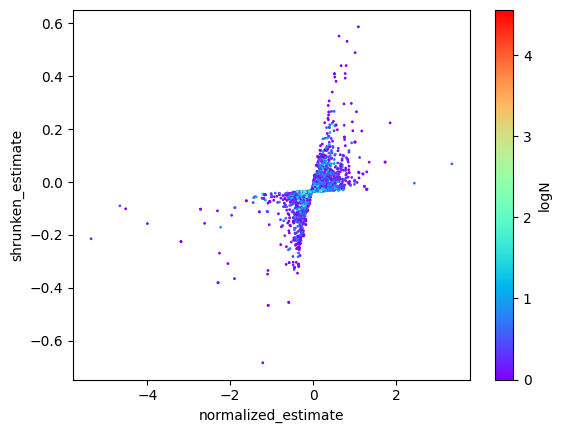

In [20]:
table.eval("logN = log(N_eff)") \
    .plot.scatter(x="normalized_estimate", y="shrunken_estimate", c="logN", cmap="rainbow", s=1)

<Axes: xlabel='N_eff', ylabel='shrunken_estimate'>

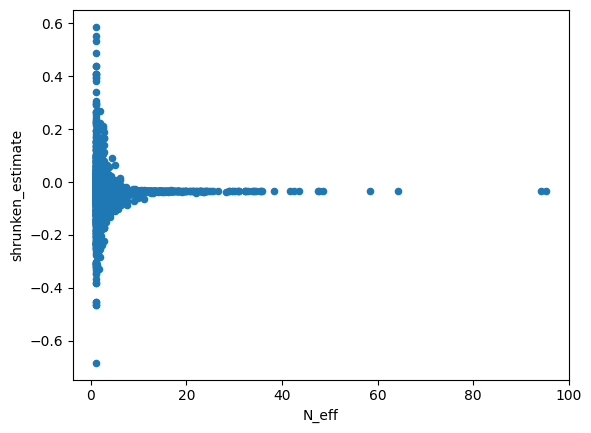

In [21]:
table.eval("logweights = log(weights)").plot.scatter(x="N_eff", y="shrunken_estimate")

<Axes: xlabel='eb_z', ylabel='naive_z'>

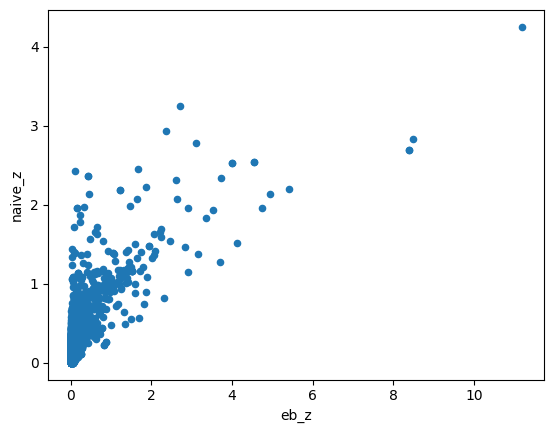

In [41]:
table.plot.scatter(x="eb_z", y="naive_z")

/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/meta_analysis/pl.py:206: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


(      gene      L2FC        SE  lower_ci  upper_ci  pct_contribution
 TCP1  TCP1 -0.329935  0.181662 -0.685993  0.026123          0.476877
 CCT4  CCT4 -0.380510  0.147327 -0.669271 -0.091750          0.523123,
 <Figure size 1100x500 with 4 Axes>,
 array([[<Axes: xlabel='log2 fold change'>, <Axes: xlabel='Contribution'>],
        [<Axes: xlabel='meta log2 fold change'>, <Axes: >]], dtype=object))

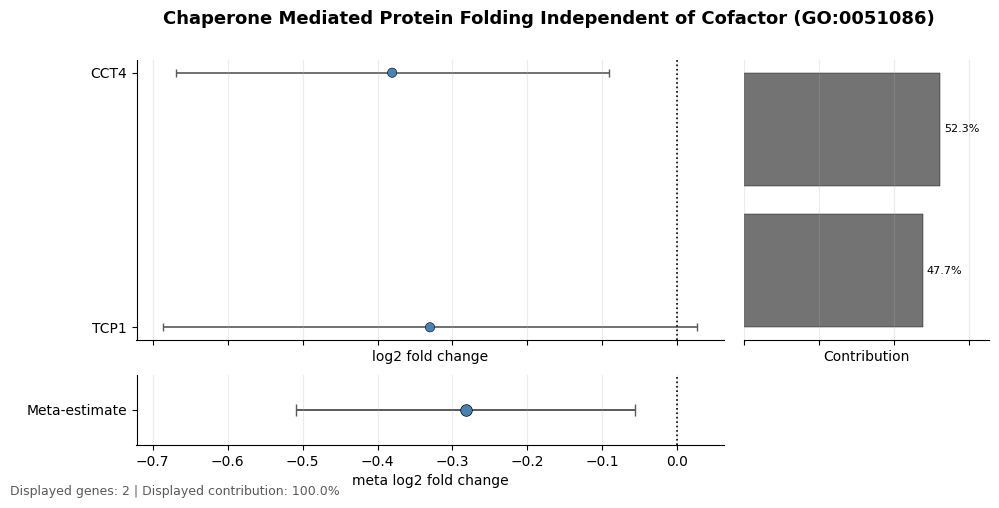

In [40]:
from meta_analysis.pl import ForestPlotter

###### SOMETHING HORRIBLE IS GOING ON HERE
ForestPlotter(df, (balanced_matrix.T * df["baseMean"]).T, table) \
    .plot_term("Chaperone Mediated Protein Folding Independent of Cofactor (GO:0051086)", cutoff=1)